# Chapter 06 — Sparse Retrieval: Inverted Index, TF-IDF, BM25

*Where we are:* the first of two retrieval arms — **lexical** matching.

```
chunks →[ inverted index → BM25 ]→ (fusion with dense) → rerank → generation
```

BM25 remains indispensable for patents: exact **technical terminology, chemical identifiers,
component numbers, claim language and rare terms** are where lexical matching beats embeddings.
We build the machinery from scratch, then use the maintained `rank-bm25`.

In [1]:
# === Chapter 06 · standard bootstrap (identical pattern in every notebook) ===
# Runs standalone on a fresh Google Colab VM *or* a local checkout.
import os, sys, subprocess

REPO_URL = "https://github.com/rsalehin/patent-rag-masterclass"
NEED_OCR = False
IN_COLAB = "google.colab" in sys.modules


def _clone_repo(url, target):
    """Clone the repo on Colab. For a PRIVATE repo, authenticate with a GitHub token read from
    Colab Secrets (key 'GITHUB_TOKEN') or the GITHUB_TOKEN env var. The token is never printed."""
    token = None
    try:
        from google.colab import userdata  # type: ignore
        token = userdata.get("GITHUB_TOKEN")
    except Exception:
        token = os.environ.get("GITHUB_TOKEN")
    auth_url = url
    if token and url.startswith("https://github.com/"):
        auth_url = url.replace("https://github.com/", f"https://{token}@github.com/")
    r = subprocess.run(["git", "clone", "--depth", "1", auth_url, target],
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)  # avoid leaking the token
    if r.returncode != 0:
        raise RuntimeError(
            "git clone failed. This is a PRIVATE repo, so Colab needs a GitHub token:\n"
            "  1) Create a token (scope: repo) at https://github.com/settings/tokens\n"
            "  2) In Colab, open the key icon (Secrets) in the left sidebar, add a secret named\n"
            "     GITHUB_TOKEN, paste the token, and enable 'Notebook access'.\n"
            "  3) Re-run this cell.\n"
            "  (Alternatively, make the GitHub repo public — then no token is needed.)")


if IN_COLAB:
    target = "/content/patent-rag-masterclass"
    if not os.path.isdir(target):
        if not REPO_URL:
            raise RuntimeError("Set REPO_URL to this repo's GitHub URL (see README.md).")
        _clone_repo(REPO_URL, target)
    os.chdir(target)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if NEED_OCR:
        subprocess.run(["apt-get", "install", "-y", "-q", "tesseract-ocr"], check=False)

# Ensure the repo root (containing patentrag/) is importable.
for _cand in [os.getcwd()] + [os.path.dirname(os.getcwd())]:
    if os.path.isdir(os.path.join(_cand, "patentrag")):
        if _cand not in sys.path:
            sys.path.insert(0, _cand)
        break

from patentrag import bootstrap as bs
bs.setup_environment(REPO_URL, need_ocr=NEED_OCR)
bs.set_seeds()
_env = bs.environment_report()
print("Chapter 06 bootstrap OK")
print("  Python", _env["python"], "| Colab:", _env["in_colab"], "| CPU cores:", _env["cpu_count"])
print("  torch", _env["torch"], "| CUDA:", _env["cuda_available"], "| tesseract:", _env["tesseract"])

Chapter 06 bootstrap OK
  Python 3.12.10 | Colab: False | CPU cores: 24
  torch 2.12.0.dev20260304+cu130 | CUDA: True | tesseract: True


## 20. The inverted index

The core data structure of every search engine: a map from **term → postings** (which documents
contain it, how often, and at which positions). We build a tiny positional index visibly.

In [2]:
from patentrag.sparse import InvertedIndex, tokenize
idx = InvertedIndex()
mini = {
    "d1": "vector index for approximate nearest neighbor search",
    "d2": "a recipe for tomato soup with basil",
    "d3": "nearest neighbor search over dense vector embeddings",
}
for did, txt in mini.items():
    idx.add(did, txt)
print("tokens of d1:", tokenize(mini["d1"]))
print("postings for 'nearest':", {d: (p.tf, p.positions) for d, p in idx.postings["nearest"].items()})
print("document frequency df('vector') =", idx.df("vector"))
print("boolean AND('nearest'):", idx.boolean_and("nearest"))

tokens of d1: ['vector', 'index', 'for', 'approximate', 'nearest', 'neighbor', 'search']
postings for 'nearest': {'d1': (1, [4]), 'd3': (1, [0])}
document frequency df('vector') = 2
boolean AND('nearest'): {'d3', 'd1'}


## 21. TF-IDF (the bridge to BM25)

$$\text{tf-idf}(t,d) = \underbrace{(1+\log f_{t,d})}_{\text{sublinear TF}}\;\cdot\;\underbrace{\log\frac{N+1}{\,df_t+1\,}+1}_{\text{smoothed IDF}}$$

where $f_{t,d}$ is the count of term $t$ in document $d$, $N$ the number of documents, and $df_t$
the number of documents containing $t$. **TF** rewards repetition (sublinearly); **IDF** rewards
rarity. TF-IDF has no length normalization and unbounded TF growth — both fixed by BM25.

In [3]:
for did, score in idx.tfidf_search("nearest neighbor vector", k=3):
    print(f"  {did}  tf-idf={score:.3f}  ::  {mini[did]}")

  d1  tf-idf=3.863  ::  vector index for approximate nearest neighbor search
  d3  tf-idf=3.863  ::  nearest neighbor search over dense vector embeddings


## 22. BM25

$$\text{BM25}(q,d)=\sum_{t\in q}\text{IDF}(t)\cdot\frac{f_{t,d}\,(k_1+1)}{f_{t,d}+k_1\big(1-b+b\,\frac{|d|}{\text{avgdl}}\big)},\qquad \text{IDF}(t)=\ln\!\Big(1+\tfrac{N-df_t+0.5}{df_t+0.5}\Big)$$

Symbol by symbol: $f_{t,d}$ term frequency; $|d|$ document length; $\text{avgdl}$ average length;
$N$ #docs; $df_t$ document frequency. **$k_1$** controls **TF saturation** (how quickly extra
occurrences stop helping); **$b\in[0,1]$** controls **length normalization** (how much long
documents are penalized). BM25 fixes TF-IDF's two flaws: TF **saturates**, and length is
**normalized**.

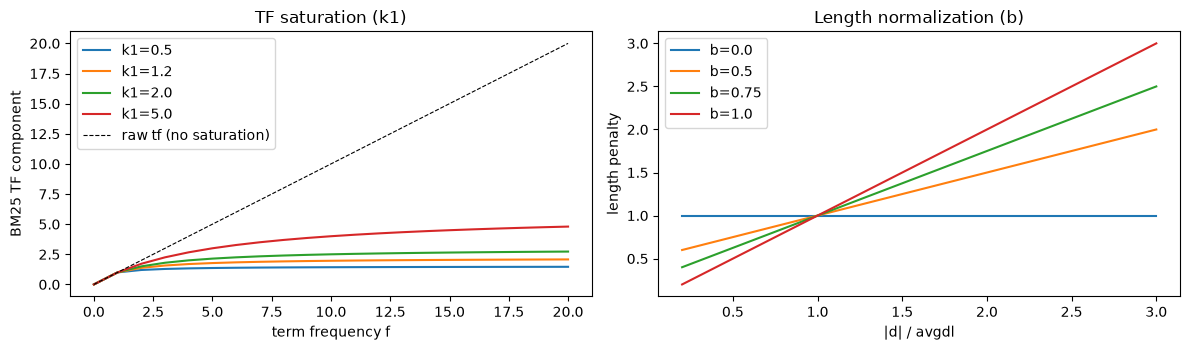

In [4]:
import numpy as np, matplotlib.pyplot as plt
# TF saturation: BM25's TF term vs raw count, for several k1
f = np.arange(0, 21)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.6))
for k1 in [0.5, 1.2, 2.0, 5.0]:
    ax1.plot(f, f*(k1+1)/(f+k1), label=f"k1={k1}")
ax1.plot(f, f, "k--", lw=0.8, label="raw tf (no saturation)")
ax1.set_xlabel("term frequency f"); ax1.set_ylabel("BM25 TF component"); ax1.legend(); ax1.set_title("TF saturation (k1)")
# length normalization: penalty factor vs |d|/avgdl for several b
ratio = np.linspace(0.2, 3, 50)
for b in [0.0, 0.5, 0.75, 1.0]:
    ax2.plot(ratio, 1 - b + b*ratio, label=f"b={b}")
ax2.set_xlabel("|d| / avgdl"); ax2.set_ylabel("length penalty"); ax2.legend(); ax2.set_title("Length normalization (b)")
plt.tight_layout(); plt.show()

### Manual BM25 vs the production library

We fit our from-scratch `BM25` and the maintained `rank_bm25` over the **corpus chunks** and
confirm they rank the same documents.

In [5]:
import pandas as pd
from patentrag.sparse import BM25
chunks = bs.ensure("chunks")
by_id = {c.chunk_id: c for c in chunks}
manual = BM25().fit([c.chunk_id for c in chunks], [c.for_index() for c in chunks])
prod = bs.ensure("bm25_index")   # rank-bm25 over the same corpus

q = "approximate nearest neighbor search over dense vectors"
man_top = [cid for cid, _ in manual.search(q, 10)]
prod_top = [cid for cid, _ in prod.search(q, 10)]
print(f"top-10 overlap (manual vs rank-bm25): {len(set(man_top) & set(prod_top))}/10")

rows = []
for cid, score in prod.search(q, 6):
    c = by_id[cid]
    rows.append({"pub": c.publication_number, "section": c.section[:16], "score": round(score, 2),
                 "text": c.text[:56]})
pd.DataFrame(rows)

top-10 overlap (manual vs rank-bm25): 10/10


,pub,section,score,text
0,US11257279B2,Claims,16.38,The method of claim 20 further comprising: det...
1,US11257279B2,Claims,16.33,"The system of claim 1 , the operations further..."
2,US11257279B2,Claims,16.22,The non-transitory machine readable medium of ...
3,US11216459B2,DETAILED DESCRIP,16.09,Semantic search may be formulated as a “neares...
4,US11257279B2,Claims,14.89,"The system of claim 5 , wherein the operations..."
5,US11714853B2,Claims,14.43,"The storage medium of claim 10 , wherein the s..."


## Why BM25 stays vital for patents

Embeddings blur exact tokens; patents live and die on **exact strings** — CPC codes, claim
numbers, part identifiers, rare compound names. A query for a precise identifier is where BM25 is
unbeatable.

In [6]:
# Exact-identifier query: a CPC-style token that dense retrieval would smear across neighbours.
exact_q = "G06F16"
hits = prod.search(exact_q, 5)
print(f"query {exact_q!r} — BM25 finds chunks whose enrichment carries that exact CPC token:")
for cid, score in hits[:5]:
    c = by_id[cid]
    print(f"  {score:5.2f}  {c.publication_number}  {c.section[:18]}")

query 'G06F16' — BM25 finds chunks whose enrichment carries that exact CPC token:
   0.00  US10083169B1  ABSTRACT
   0.00  US10083169B1  CROSS-REFERENCE TO
   0.00  US10083169B1  BACKGROUND
   0.00  US10083169B1  BACKGROUND
   0.00  US10083169B1  BACKGROUND


**Production implications.** BM25 is cheap, exact, and needs no model — always keep it in the
stack. Its weakness is vocabulary mismatch (a searcher's words ≠ the patentee's words), which is
exactly what dense retrieval (next chapter) repairs. `k1`/`b` are worth tuning per corpus;
Lucene/Pyserini are the production engines when scale demands it.

## Chapter invariants

In [7]:
from patentrag.sparse import bm25_idf
assert len(set(man_top) & set(prod_top)) >= 8            # manual ≈ production
assert bm25_idf(1000, 1) > bm25_idf(1000, 500)           # rarer term → higher IDF
assert tokenize("G06F16/2457 ph-value 3.5") == ["g06f16/2457", "ph-value", "3.5"]
assert idx.df("nearest") == 2 and idx.boolean_and("soup") == {"d2"}
print("All Chapter 06 invariants hold. bm25_index artifact ready.")

All Chapter 06 invariants hold. bm25_index artifact ready.


In [8]:
# === Chapter 06 validation footer ===
import time, platform, sys, importlib.metadata as _md
_pkgs = ['rank-bm25', 'numpy', 'matplotlib']
print("Chapter 06 — environment")
print("  Python :", sys.version.split()[0], "on", platform.system(), platform.release())
for _p in _pkgs:
    try: print(f"  {_p:24}: {_md.version(_p)}")
    except Exception: print(f"  {_p:24}: (not installed)")
print()
print("CHAPTER 06 VALIDATION: PASS")

Chapter 06 — environment
  Python : 3.12.10 on Windows 11
  rank-bm25               : 0.2.2
  numpy                   : 2.4.2
  matplotlib              : 3.11.1

CHAPTER 06 VALIDATION: PASS
